# Notebook 1: Base CLIP on a Full Test Image

This notebook runs zero-shot **base CLIP** directly on one image from `testing/`.
It does not use pose estimation or segmentation. Instead, it asks CLIP whether each limb
appears injured or not from the full image context.


## What This Notebook Shows

- Load one test image
- Run base `ViT-B/16` CLIP
- Score each limb with prompts like `left arm is injured` vs `left arm is not injured`
- Display a clean summary of what CLIP thinks


In [1]:
from pathlib import Path
import html
import os
import sys

import certifi
import matplotlib.pyplot as plt
import torch
from PIL import Image
from IPython.display import display, HTML

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
CLIP_LORA_DIR = PROJECT_ROOT / "CLIP-LoRA"
if str(CLIP_LORA_DIR) not in sys.path:
    sys.path.insert(0, str(CLIP_LORA_DIR))

import clip

IMAGE_PATH = PROJECT_ROOT / "testing/001.png"
BACKBONE = "ViT-B/16"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LIMB_PROMPTS = {
    "left_arm": ["The person's left arm is injured.", "The person's left arm is not injured."],
    "right_arm": ["The person's right arm is injured.", "The person's right arm is not injured."],
    "left_leg": ["The person's left leg is injured.", "The person's left leg is not injured."],
    "right_leg": ["The person's right leg is injured.", "The person's right leg is not injured."],
}


def load_base_clip(backbone: str, device: str):
    os.environ["SSL_CERT_FILE"] = certifi.where()
    try:
        model, preprocess = clip.load(backbone, device=device)
    except Exception as exc:
        if "CERTIFICATE_VERIFY_FAILED" in str(exc):
            os.environ["PYTHONHTTPSVERIFY"] = "0"
            model, preprocess = clip.load(backbone, device=device)
        else:
            raise
    model.eval()
    return model, preprocess


def render_table(records):
    headers = ["Limb", "Predicted Status", "Injury Prob", "No-Injury Prob"]
    rows = []
    for item in records:
        rows.append(
            "<tr>"
            f"<td>{html.escape(item['limb'])}</td>"
            f"<td>{html.escape(item['predicted_status'])}</td>"
            f"<td>{item['injury_prob']:.4f}</td>"
            f"<td>{item['no_injury_prob']:.4f}</td>"
            "</tr>"
        )
    table_html = (
        "<table style='border-collapse:collapse; width:100%;'>"
        "<thead><tr>"
        + "".join(
            f"<th style='border:1px solid #d0d7de; padding:8px; background:#f6f8fa; text-align:left;'>{h}</th>"
            for h in headers
        )
        + "</tr></thead><tbody>"
        + "".join(rows)
        + "</tbody></table>"
    )
    display(HTML(table_html))


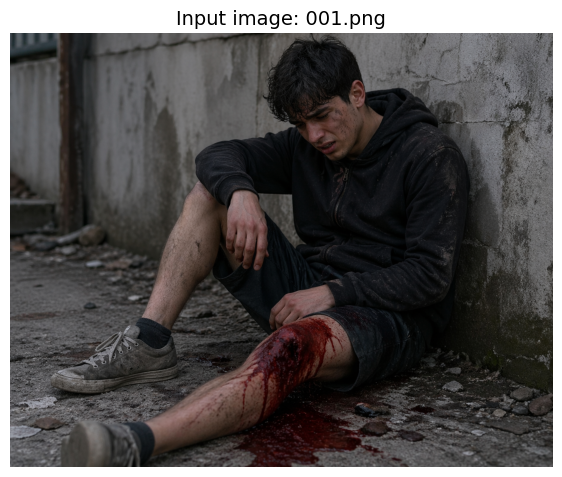

In [2]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

clip_model, preprocess = load_base_clip(BACKBONE, DEVICE)
image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.title(f"Input image: {IMAGE_PATH.name}", fontsize=14)
plt.axis("off")
plt.show()


In [3]:
image_tensor = preprocess(image).unsqueeze(0).to(DEVICE)
records = []

with torch.no_grad():
    image_features = clip_model.encode_image(image_tensor)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    for limb_name, prompts in LIMB_PROMPTS.items():
        tokens = clip.tokenize(prompts).to(DEVICE)
        text_features = clip_model.encode_text(tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        logits = 100.0 * image_features @ text_features.t()
        probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()

        pred_binary = "injured" if probs[0] >= probs[1] else "not injured"
        records.append(
            {
                "limb": limb_name.replace("_", " "),
                "predicted_status": pred_binary,
                "injury_prob": float(probs[0]),
                "no_injury_prob": float(probs[1]),
            }
        )

render_table(records)
injured_limbs = [item["limb"] for item in records if item["predicted_status"] == "injured"]
print("Base CLIP says injured limbs:", injured_limbs if injured_limbs else "none")


Limb,Predicted Status,Injury Prob,No-Injury Prob
left arm,injured,0.6825,0.3175
right arm,injured,0.6221,0.3779
left leg,injured,0.6920,0.3080
right leg,injured,0.6437,0.3563


Base CLIP says injured limbs: ['left arm', 'right arm', 'left leg', 'right leg']


## Why The Results Can Be Weak

This notebook uses zero-shot CLIP on the full image without pose detection, cropping, or masking. That means the model is asked to judge a local limb condition from global image context, so the signal is weak and the outputs can look noisy or overconfident. A stronger setup is the later notebooks, where YOLO isolates the limbs first and CLIP scores only the limb-focused region.